# 03 Análise de Completude (CNEFE vs BHMap)

**Objetivo:** Avaliar a quantidade de registros do CNEFE que não encontraram par no BHMap ("Orphans" num raio de 50m) e explorar a taxa de preenchimento (completude) dos atributos essenciais, gerando métricas descritivas cruciais para a dissertação.

**Entrada:**
- `data/interim/cnefe_match_bhmap.parquet`

**Saídas:**
- Gráficos em `outputs/figures/03_completeness_barchart.png`


In [1]:
import sys
import os
from pathlib import Path

os.chdir('..')
sys.path.append(os.getcwd())

%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src import config
from src.metrics import calculate_completeness
from src.maps import plot_completeness_bar_chart


## 1. Carregamento dos Dados

In [2]:
print("Carregando cnefe_match_bhmap.parquet...")
gdf_matched = gpd.read_parquet(config.INTERIM_DATA_DIR / "cnefe_match_bhmap.parquet")
print(f"Total de registros: {len(gdf_matched):,}")


Carregando cnefe_match_bhmap.parquet...


Total de registros: 1,180,102


## 2. Análise de Órfãos (Failed Matches)
Um registro é considerado órfão nesta análise se o Match Certainty Indicator (MCI) for exatamente 0.0, o que ocorre quando não há candidatos a um raio de 50 metros ou os nomes divergem completamente.

Total de Órfãos: 17,516 (1.48% do CNEFE)


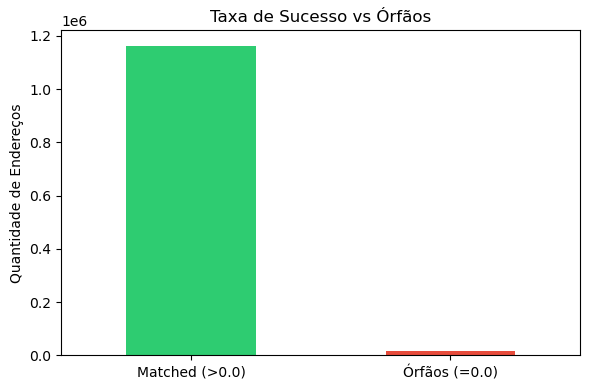

In [3]:
orphans = gdf_matched[gdf_matched['MCI'] == 0.0]
orphan_count = len(orphans)
total = len(gdf_matched)
orphan_rate = (orphan_count / total) * 100

print(f"Total de Órfãos: {orphan_count:,} ({orphan_rate:.2f}% do CNEFE)")

# Visualização Simples
fig, ax = plt.subplots(figsize=(6,4))
orphans_series = pd.Series({'Matched (>0.0)': total - orphan_count, 'Órfãos (=0.0)': orphan_count})
orphans_series.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title("Taxa de Sucesso vs Órfãos")
ax.set_ylabel("Quantidade de Endereços")
plt.xticks(rotation=0)
sns_despine = getattr(plt, 'despine', lambda: None)
sns_despine()
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "03_orphan_rate_bar.png", dpi=300)


## 3. Avaliação de Completude de Atributos
Agora vamos avaliar quão preenchidos estão os campos do CNEFE. Registros "Vazios" ou "NaN" serão contabilizados como falta de informação.

,Attribute,Valid Count,Missing Count,Completeness (%)
0,std_logradouro_completo,1180102,0,100.00
1,std_numero,0,1180102,0.00
2,LOGRAD_NUM,1180102,0,100.00
3,DSC_LOCALIDADE,1180102,0,100.00
4,COMPLEMENTO,690016,490086,58.47


C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\src\visualization\maps.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved bar chart to C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\outputs\figures\03_cnefe_attributes_completeness.png


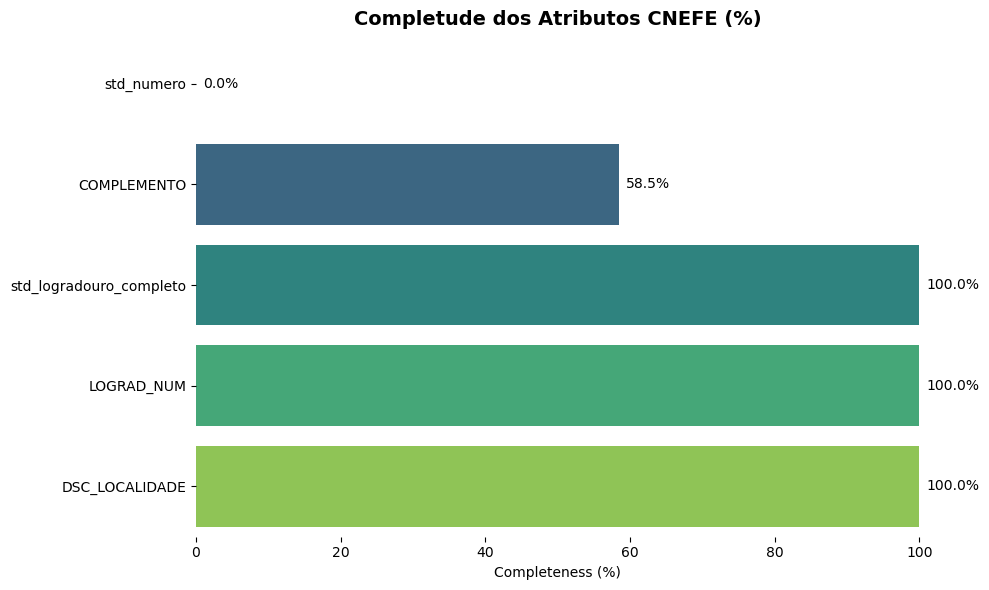

In [4]:
# Atributos essenciais do CNEFE para analisar completude
cols_to_check = [
    'std_logradouro_completo',
    'std_numero', # Not present usually in CNEFE out-of-the-box, but check if we added it in normalization
    'LOGRAD_NUM',
    'std_bairro',
    'std_cep',
    'std_municipio',
    'DSC_LOCALIDADE',
    'COMPLEMENTO'
]

# Keep only those present in df
cols_to_check = [c for c in cols_to_check if c in gdf_matched.columns]

# Calcular Completude
df_completeness = calculate_completeness(gdf_matched, cols_to_check)
display(df_completeness)

# Plotar e Salvar o Gráfico
fig, ax = plot_completeness_bar_chart(
    df_completeness, 
    output_path=str(config.FIGURES_DIR / "03_cnefe_attributes_completeness.png"),
    title="Completude dos Atributos CNEFE (%)"
)
